# TAREA: CASO DE NEGOCIO EN EDUCACIÓN

## Paso 1: Generación de Datos Sintéticos con Patrones Visuales

In [1]:
# Importamos bibliotecas a utilizar
import numpy as np
import pandas as pd

# Reproducibilidad
np.random.seed(42)

# Definir número de cursos
n_cursos = 300

# Crear etiquetas latentes para tres tipos de cursos (no se muestran al estudiante)
# 0 = énfasis en planificación, 1 = énfasis en enseñanza, 2 = énfasis en aprendizaje
grupo = np.random.choice([0, 1, 2], size=n_cursos, p=[0.33, 0.34, 0.33])

# Inicializar array vacío
datos = []

# Generar cada fila del dataset según el grupo
for g in grupo:
    if g == 0: # Fuerte en planificación
        f1 = np.random.normal(4.5, 0.3)
        f2 = np.random.normal(3.0, 0.4)
        f3 = np.random.normal(2.5, 0.4)
    elif g == 1: # Fuerte en enseñanza
        f1 = np.random.normal(3.0, 0.4)
        f2 = np.random.normal(4.5, 0.3)
        f3 = np.random.normal(2.5, 0.4)
    else: # Fuerte en aprendizaje
        f1 = np.random.normal(3.0, 0.4)
        f2 = np.random.normal(2.5, 0.4)
        f3 = np.random.normal(4.5, 0.3)
    # Añadir ruido leve a cada variable del grupo
    fila = [
        f1 + np.random.normal(0, 0.2), # Claridad del plan de curso
        f1 + np.random.normal(0, 0.2), # Definición de objetivos de aprendizaje
        f1 + np.random.normal(0, 0.2), # Adecuación del cronograma
        f2 + np.random.normal(0, 0.2), # Actualización del contenido
        f2 + np.random.normal(0, 0.2), # Uso de recursos tecnológicos
        f2 + np.random.normal(0, 0.2), # Estrategias didácticas
        f2 + np.random.normal(0, 0.2), # Claridad en la exposición
        f2 + np.random.normal(0, 0.2), # Evaluación formativa
        f3 + np.random.normal(0, 0.2), # Participación estudiantil
        f3 + np.random.normal(0, 0.2), # Autonomía promovida
        f3 + np.random.normal(0, 0.2), # Evidencias de aprendizaje
        f3 + np.random.normal(0, 0.2) # Retroalimentación recibida
    ]
    datos.append(fila)
    
# Convertir a DataFrame
columnas = [
    "Claridad_plan_curso", "Def_obj_aprendizaje", "Adecuacion_cronograma",
    "Actualizacion_contenido", "Uso_recursos_tecnologicos", "Estrategias_didacticas",
    "Claridad_exposicion_docente", "Eval_formativa_frecuente",
    "Participacion_estudiantes", "Autonomia_promovida",
    "Evidencia_aprendizaje", "Retroalimentacion_recibida"
]
data = pd.DataFrame(datos, columns=columnas)

# Limitar valores a escala de 1 a 5
data = data.clip(lower=1, upper=5)

# Vista previa
data.head()

,Claridad_plan_curso,Def_obj_aprendizaje,Adecuacion_cronograma,Actualizacion_contenido,Uso_recursos_tecnologicos,Estrategias_didacticas,Claridad_exposicion_docente,Eval_formativa_frecuente,Participacion_estudiantes,Autonomia_promovida,Evidencia_aprendizaje,Retroalimentacion_recibida
0,3.145013,2.613200,3.055520,4.172163,4.475007,4.146016,4.281573,4.405517,3.530729,3.117518,3.290677,3.262589
1,2.486492,2.922241,3.163100,3.412675,2.902308,3.109335,3.459564,3.064648,4.710258,4.776421,4.436108,4.609589
2,1.453936,2.029975,1.417465,2.002236,2.116393,2.378500,1.803073,2.322878,4.426276,4.227928,4.516650,4.464041
3,2.782617,2.892339,3.077117,4.273378,4.947547,4.130523,4.490584,4.638604,2.402073,2.221335,2.304250,2.247274
4,4.184609,4.503111,4.384650,3.502413,3.465767,3.174042,3.227805,3.489300,2.764880,2.638626,2.666272,2.898339


**Explicación breve:**
En este primer paso estamos generando un dataset ficticio de 300 cursos, donde cada curso se clasifica con énfasis en planificación, enseñanza o aprendizaje. Según el grupo, se crean calificaciones simuladas (en escala 1 a 5) para distintos aspectos del curso y se guardan en un DataFrame de pandas.

## Paso 2: Revisión y Visualización Inicial de la Data

Dimensiones: (300, 12)

¿Valores nulos?
 Claridad_plan_curso            0
Def_obj_aprendizaje            0
Adecuacion_cronograma          0
Actualizacion_contenido        0
Uso_recursos_tecnologicos      0
Estrategias_didacticas         0
Claridad_exposicion_docente    0
Eval_formativa_frecuente       0
Participacion_estudiantes      0
Autonomia_promovida            0
Evidencia_aprendizaje          0
Retroalimentacion_recibida     0
dtype: int64

Rango de valores:
Claridad_plan_curso            1.453936
Def_obj_aprendizaje            1.750540
Adecuacion_cronograma          1.417465
Actualizacion_contenido        1.000000
Uso_recursos_tecnologicos      1.643679
Estrategias_didacticas         1.578175
Claridad_exposicion_docente    1.311401
Eval_formativa_frecuente       1.332335
Participacion_estudiantes      1.342620
Autonomia_promovida            1.303933
Evidencia_aprendizaje          1.331064
Retroalimentacion_recibida     1.310360
dtype: float64
Claridad_plan_curso            5.0
D

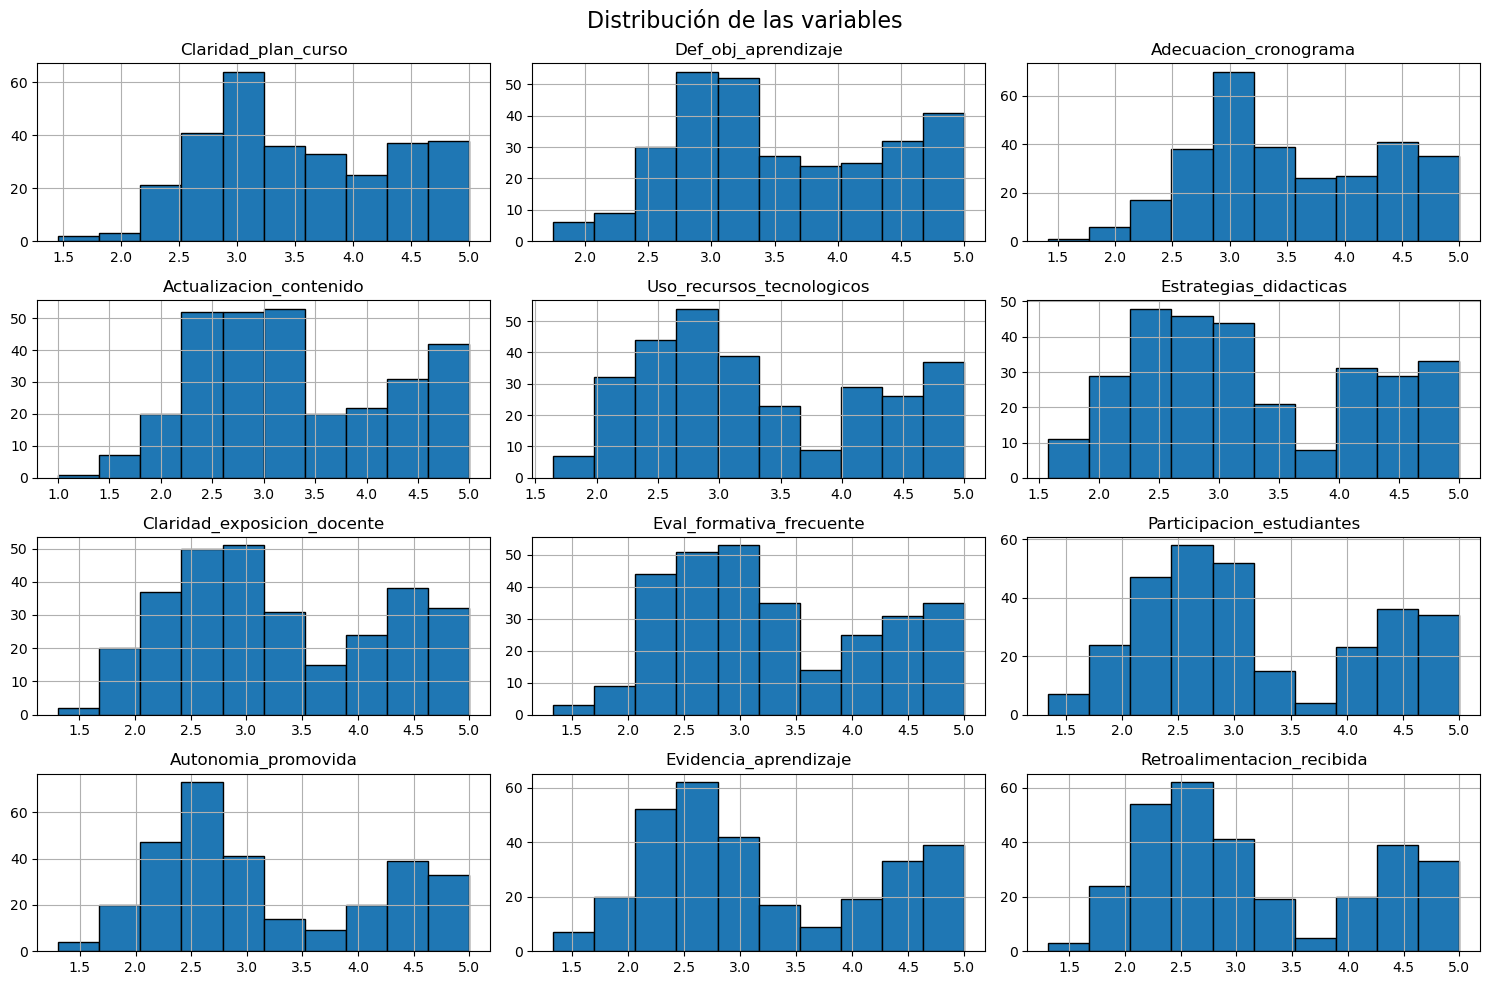

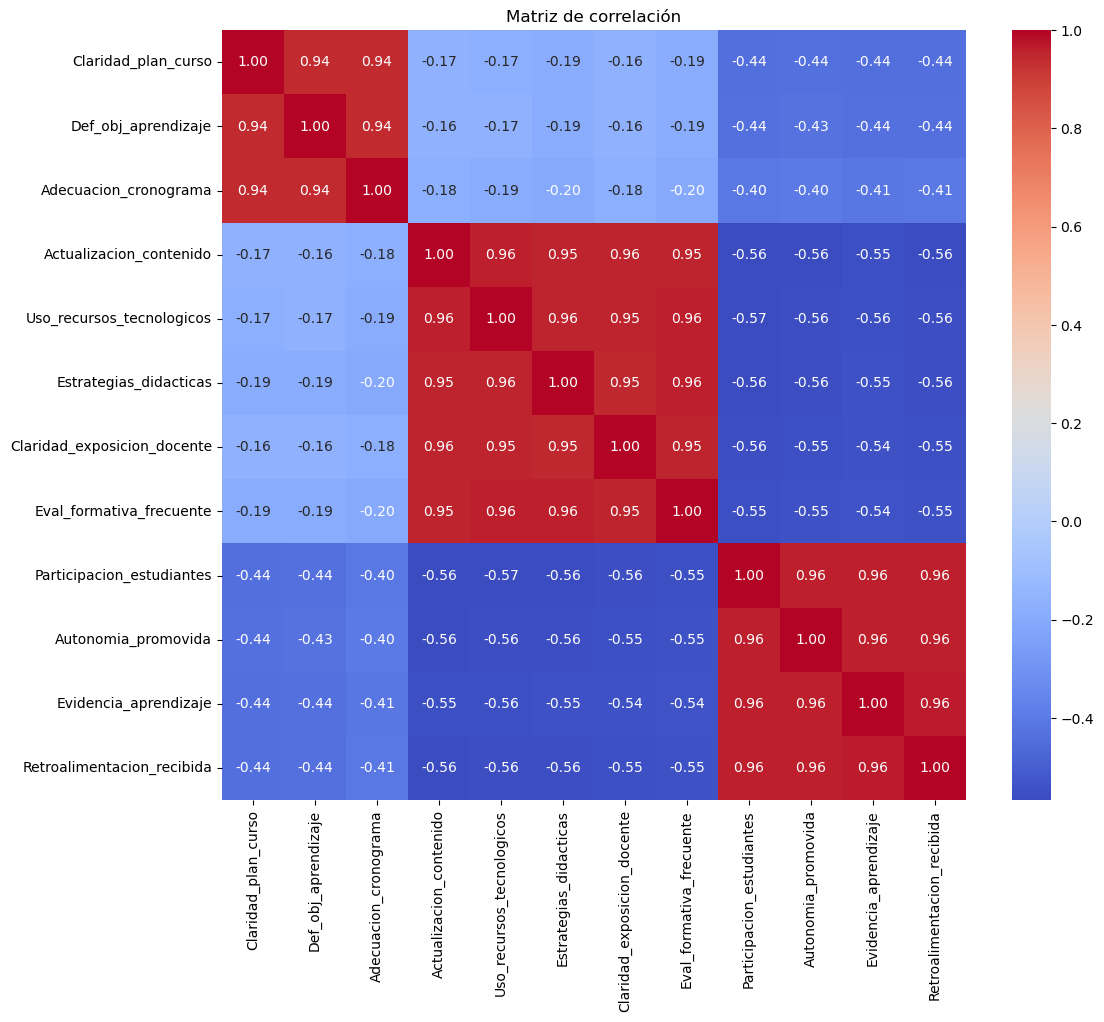

In [4]:
# Revisar estructura y valores
print("Dimensiones:", data.shape)
print("\n¿Valores nulos?\n", data.isnull().sum())
print("\nRango de valores:")
print(data.min())
print(data.max())
print("\nResumen estadístico:")
print(data.describe())

# Histogramas
import matplotlib.pyplot as plt
data.hist(figsize=(15, 10), bins=10, edgecolor='black')
plt.suptitle("Distribución de las variables", fontsize=16)
plt.tight_layout()
plt.show()

# Heatmap de correlación
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

**Explicación breve**
- Los **histogramas** muestran cómo se “reparten” las calificaciones de cada aspecto del curso.  
- En el **heatmap (mapa de calor) de correlaciones**:
  - *Actualización_contenido*, *Uso_recursos_tecnológicos* y *Estrategias_didácticas* tienen correlaciones muy altas (~0.95), lo que indica que suelen subir o bajar juntas.  
  - *Claridad_plan_curso* y *Def_obj_aprendizaje* presentan correlación fuerte entre sí (~0.94), pero se relacionan **negativamente** con *Participación_estudiantes* y *Autonomía_promovida*.  

## Paso 3: Aplicación PCA

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=2c87919c017cbe53b57c89ffcad4e49ca56cb08588cf509cb888a355399f4b2f
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer
Determinante de la matriz de correlación: 0.000000
KMO general: 0.9269
   Componente  Autovalor  Varianza %  Acumulado %
0          C1       6.95       57.71        57.71
1          C2       4.00       33.24        90.95
2          C3       0.68        5.68        96.62
3          C4       0.06        0.51        97.13
4          C5       0.06        0.46        97.60
5          C6       0.05        0.43        98.02
6          C7       0.05        0.39        98.41
7          C8       0.05        0.38        98.79
8          C9       0.04      

/opt/conda/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


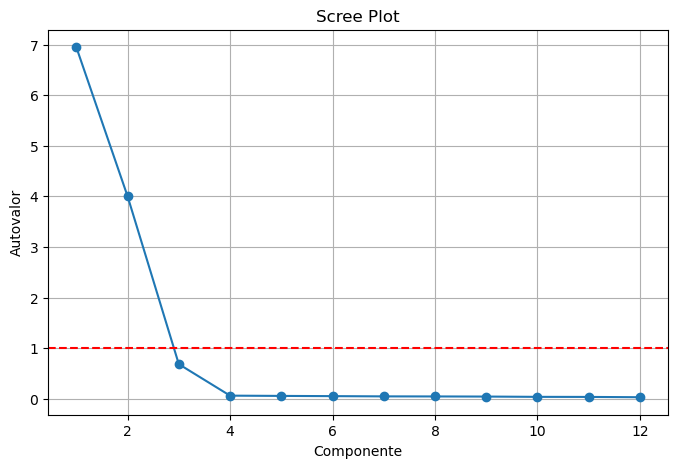


Matriz de Componentes (Loadings):
                             Componente_1  Componente_2
Claridad_plan_curso                 0.069         0.464
Def_obj_aprendizaje                 0.069         0.463
Adecuacion_cronograma               0.059         0.461
Actualizacion_contenido             0.333        -0.202
Uso_recursos_tecnologicos           0.333        -0.205
Estrategias_didacticas              0.332        -0.210
Claridad_exposicion_docente         0.331        -0.202
Eval_formativa_frecuente            0.330        -0.213
Participacion_estudiantes          -0.332        -0.189
Autonomia_promovida                -0.330        -0.188
Evidencia_aprendizaje              -0.329        -0.193
Retroalimentacion_recibida         -0.330        -0.190


In [8]:
!pip install factor_analyzer

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo

# Escalar datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Determinante
correlation_matrix = np.corrcoef(data_scaled.T)
print(f"Determinante de la matriz de correlación: {np.linalg.det(correlation_matrix):.6f}")

# KMO
_, kmo = calculate_kmo(data_scaled)
print(f"KMO general: {kmo:.4f}")

# PCA completo
pca = PCA()
pca.fit(data_scaled)
autovalores = pca.explained_variance_

# Tabla de varianza explicada
var_exp = pd.DataFrame({
    "Componente": [f"C{i+1}" for i in range(len(autovalores))],
    "Autovalor": autovalores,
    "Varianza %": pca.explained_variance_ratio_ * 100,
    "Acumulado %": np.cumsum(pca.explained_variance_ratio_) * 100
})
print(var_exp.round(2))

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(autovalores)+1), autovalores, marker='o')
plt.axhline(y=1, color='red', linestyle='--')
plt.title("Scree Plot")
plt.xlabel("Componente")
plt.ylabel("Autovalor")
plt.grid(True)
plt.show()

# Matriz de componentes
n_retener = sum(autovalores > 1)
cargas = pd.DataFrame(
    pca.components_.T[:, :n_retener],
    columns=[f"Componente_{i+1}" for i in range(n_retener)],
    index=data.columns
)
print("\nMatriz de Componentes (Loadings):")
print(cargas.round(3))

##### 🎯 Resultados del PCA

El análisis de **componentes principales (PCA)** reduce las **12 variables** a **2 factores principales**:

- **Componente 1 (Enseñanza y recursos)** → ligado a *actualización del contenido*, *uso de tecnología* y *estrategias didácticas*.  
- **Componente 2 (Planificación del curso)** → ligado a *claridad del plan*, *definición de objetivos* y *adecuación del cronograma*.  


## Paso 4: Visualizacion de los componentes

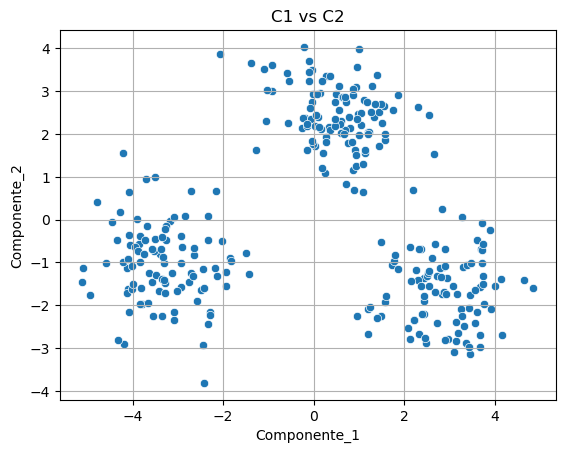

In [9]:
from mpl_toolkits.mplot3d import Axes3D

# Proyección de datos con las componentes retenidas
pca_final = PCA(n_components=n_retener)
data_proj = pca_final.fit_transform(data_scaled)
df_pca = pd.DataFrame(data_proj, columns=[f"Componente_{i+1}" for i in range(n_retener)])

# Gráfico 3D (solo si hay al menos 3 componentes retenidos)
if n_retener >= 3:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df_pca["Componente_1"], df_pca["Componente_2"], df_pca["Componente_3"],
               c='skyblue', s=50, alpha=0.7)
    ax.set_title("Visualización 3D de los Componentes Principales")
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    ax.set_zlabel("Componente 3")
    plt.show()

# Gráficos 2D (siempre disponibles)
if n_retener >= 2:
    sns.scatterplot(x="Componente_1", y="Componente_2", data=df_pca).set_title("C1 vs C2")
    plt.grid(True)
    plt.show()

if n_retener >= 3:
    sns.scatterplot(x="Componente_2", y="Componente_3", data=df_pca).set_title("C2 vs C3")
    plt.grid(True)
    plt.show()

    sns.scatterplot(x="Componente_1", y="Componente_3", data=df_pca).set_title("C1 vs C3")
    plt.grid(True)
    plt.show()

**Visualización PCA (C1 vs C2)**

El gráfico muestra la proyección de los cursos en los **dos primeros componentes principales**:

- **Componente 1 (Eje X)** → representa principalmente *enseñanza y recursos*.  
- **Componente 2 (Eje Y)** → representa principalmente *planificación del curso*.  

Se observan **tres grupos bien definidos**, lo que refleja los diferentes tipos de cursos simulados:  
1. Cursos con énfasis en **planificación**.  
2. Cursos con énfasis en **enseñanza**.  
3. Cursos con énfasis en **aprendizaje**.  

👉 El PCA reduce la información a 2 dimensiones y facilita visualizar la **separación natural entre los grupos**.


## Paso 5: Interpretación de Componentes, Recomendaciones y Programa de Intervención

##### 🅰 Interpretación de los Componentes  

Tras el PCA se identificaron **2 componentes principales**:  

- **Componente 1 (Enseñanza y recursos):** asociado a *actualización de contenidos, uso de tecnología y estrategias didácticas*.  
- **Componente 2 (Planificación académica):** ligado a *claridad del plan, definición de objetivos y adecuación del cronograma*.  

👉 Esto muestra que los cursos se diferencian principalmente por la calidad de su **planificación** y por el uso de **estrategias de enseñanza**.  

---

##### 🅱 Recomendaciones Estratégicas  

Con base en la interpretación anterior, la institución podría:  
1. **Revisar la planificación académica** en cursos con bajos puntajes en el Componente 2.  
2. **Capacitar docentes** en metodologías activas, o nuevas, y uso de recursos, si los valores del Componente 1 son bajos.  

---

##### 🅲 Programa de Intervención Educativa Propuesto  

**Ejes del programa:**  

| Eje            | Acción propuesta                                                   | Responsable              | Indicador                           |
|----------------|--------------------------------------------------------------------|--------------------------|--------------------------------------|
| Planificación  | Taller de rediseño curricular con foco en objetivos y cronograma   | Coordinadores académicos | % de sílabos mejorados               |
| Enseñanza      | Capacitación en metodologías activas y uso de tecnología           | Centro de innovación     | Evaluación docente > 4.0             |